# Fase 2 — Variáveis derivadas fisicamente

Objetivo: construir e caracterizar combinações meteorológicas derivadas dos 12 canais ERA5 sem alterar o dataset de treinamento. As grandezas de diferença vetorial de vento são **proxies de cisalhamento em m/s**, não taxas de cisalhamento normalizadas por altura.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

def resolve_output(rel):
    candidates = [Path(rel), Path("..") / rel, Path.cwd() / rel, Path.cwd().parent / rel]
    for p in candidates:
        if p.exists():
            return p.resolve()
    return Path(rel).resolve()

OUT = resolve_output("analysis_outputs/02_derived")
print("Usando resultados em:", OUT)


Usando resultados em: /home/vsantos/repositories/rionowcastdf/analysis_outputs/02_derived


In [2]:
def load_parquet(name):
    path = OUT / name
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

def load_json(name):
    path = OUT / name
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

summary = load_json("analysis_summary.json")
formulas = load_parquet("formula_catalog.parquet")
derived = load_parquet("derived_summary.parquet")
quantiles = load_parquet("derived_quantiles.parquet")
hist = load_parquet("derived_histograms.parquet")
corr_long = load_parquet("derived_correlations.parquet")
samples_file = OUT / "derived_samples.npz"
samples = np.load(samples_file, allow_pickle=False) if samples_file.exists() else None


## 1. Catálogo das variáveis derivadas

In [3]:
formulas

,name,formula,unit,interpretation
0,wind_speed_10,sqrt(u10^2 + v10^2),m s^-1,Magnitude do vento a 10 m.
1,wind_speed_850,sqrt(u_850^2 + v_850^2),m s^-1,Magnitude do vento em 850 hPa.
2,wind_speed_500,sqrt(u_500^2 + v_500^2),m s^-1,Magnitude do vento em 500 hPa.
3,delta_t_500_850,t_500 - t_850,K,Diferença vertical de temperatura 500-850 hPa.
4,delta_t_850_surface,t_850 - t2m,K,Diferença de temperatura entre 850 hPa e 2 m.
5,delta_r_500_850,r_500 - r_850,percentage points,Diferença de umidade relativa 500-850 hPa.
6,bulk_wind_diff_10_850,sqrt((u_850-u10)^2 + (v_850-v10)^2),m s^-1,Diferença vetorial de vento 10 m-850 hPa; prox...
7,bulk_wind_diff_850_500,sqrt((u_500-u_850)^2 + (v_500-v_850)^2),m s^-1,Diferença vetorial de vento 850-500 hPa; proxy...


## 2. Resumo estatístico

In [4]:
cols=["name","unit","sampled_pixel_count","mean","std","min","max","skewness_reservoir","excess_kurtosis_reservoir"]
derived[cols] if not derived.empty else derived

,name,unit,sampled_pixel_count,mean,std,min,max,skewness_reservoir,excess_kurtosis_reservoir
0,wind_speed_10,m s^-1,33554432,3.015646,2.129252,0.000853,14.140887,1.185488,1.125092
1,wind_speed_850,m s^-1,33554432,4.910199,2.871872,0.002134,22.517418,1.082452,1.502892
2,wind_speed_500,m s^-1,33554432,11.458192,5.963923,0.001984,33.937737,0.649792,0.262123
3,delta_t_500_850,K,33554432,-23.106042,2.812282,-31.735901,-13.463013,0.241987,-0.026942
4,delta_t_850_surface,K,33554432,-7.629093,2.654625,-16.182220,4.962921,0.206538,-0.019974
5,delta_r_500_850,percentage points,33554432,-40.804900,32.321213,-100.966484,54.198380,0.361153,-0.727235
6,bulk_wind_diff_10_850,m s^-1,33554432,4.893306,2.902964,0.000613,22.357376,0.935020,1.067142
7,bulk_wind_diff_850_500,m s^-1,33554432,10.784162,6.175218,0.004137,37.600304,0.740446,0.399790


## 3. Quantis

In [5]:
if not quantiles.empty:
    display(quantiles.pivot(index="name", columns="quantile", values="value"))

quantile,p001,p01,p05,p25,p50,p75,p95,p99,p999
name,,,,,,,,,
bulk_wind_diff_10_850,0.155737,0.485541,1.091627,2.692445,4.418283,6.566023,10.363710,13.274748,17.557894
bulk_wind_diff_850_500,0.327867,1.042665,2.405765,6.002422,9.902160,14.611844,21.830544,28.245981,35.127079
delta_r_500_850,-98.038841,-95.393265,-87.677246,-66.722771,-44.700958,-16.827763,16.449163,32.591270,41.469242
delta_t_500_850,-30.398073,-28.988619,-27.676544,-25.014359,-23.226105,-21.342300,-18.216078,-15.845703,-14.524047
delta_t_850_surface,-14.793732,-13.362746,-11.772728,-9.514069,-7.701050,-5.871635,-3.114562,-1.027802,1.099399
wind_speed_10,0.089625,0.277059,0.610472,1.416885,2.436107,4.095419,7.414382,9.560255,11.515213
wind_speed_500,0.639149,1.583204,3.103712,6.782090,10.966438,15.073521,21.995028,29.034451,31.731285
wind_speed_850,0.178923,0.580775,1.254071,2.791245,4.344126,6.498165,10.369065,14.018874,17.198242


## 4. Distribuições das variáveis derivadas

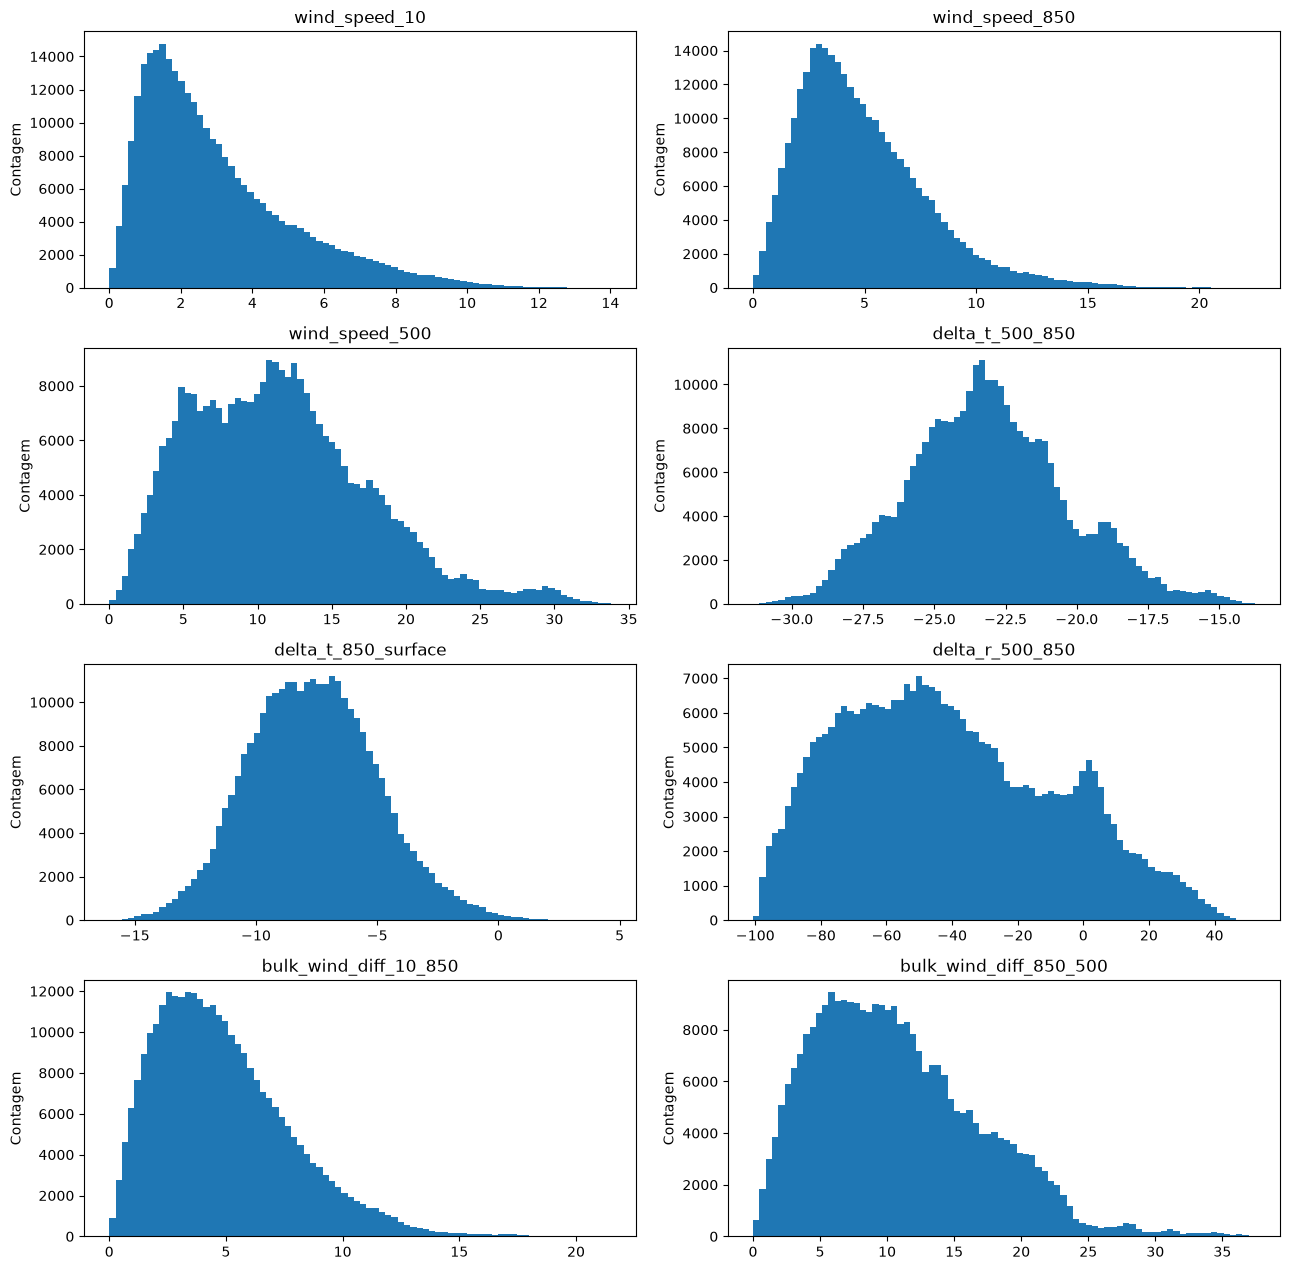

In [6]:
if samples is not None:
    names=list(samples.files)
    ncols=2
    nrows=int(np.ceil(len(names)/ncols))
    fig, axes=plt.subplots(nrows,ncols,figsize=(13,3.2*nrows))
    axes=np.asarray(axes).reshape(-1)
    for ax,name in zip(axes,names):
        vals=samples[name]
        ax.hist(vals,bins=80)
        ax.set_title(name)
        ax.set_ylabel("Contagem")
    for ax in axes[len(names):]: ax.axis("off")
    fig.tight_layout()
    plt.show()

## 5. Magnitude do vento nos três níveis

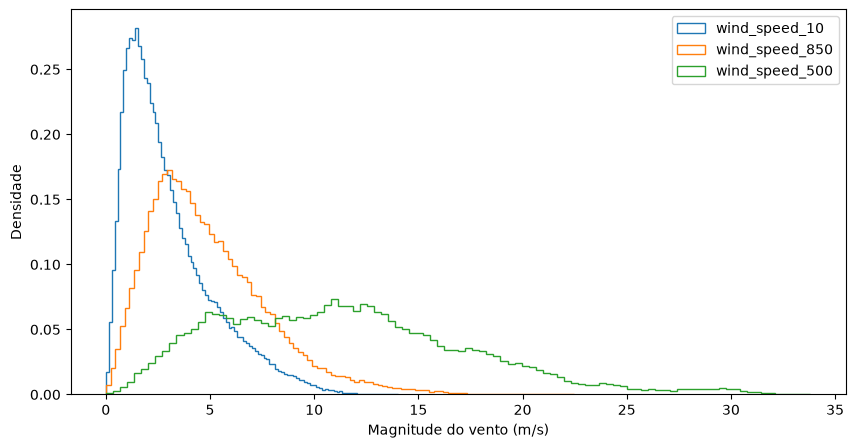

In [7]:
if samples is not None:
    fig, ax=plt.subplots(figsize=(10,5))
    for name in ["wind_speed_10","wind_speed_850","wind_speed_500"]:
        vals=samples[name]
        ax.hist(vals,bins=100,density=True,histtype="step",label=name)
    ax.set_xlabel("Magnitude do vento (m/s)")
    ax.set_ylabel("Densidade")
    ax.legend()
    plt.show()

## 6. Estrutura vertical termodinâmica

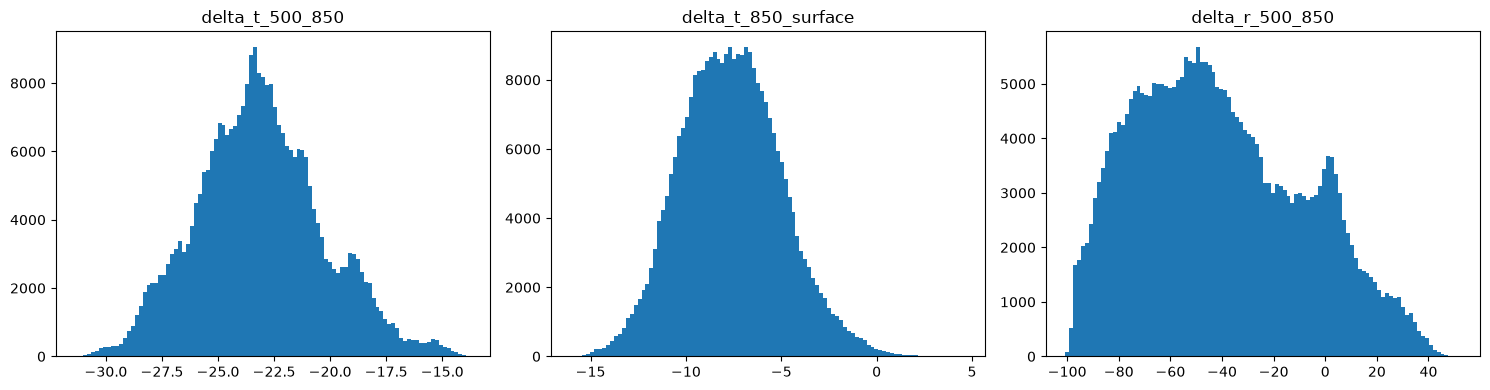

In [8]:
if samples is not None:
    fig, axes=plt.subplots(1,3,figsize=(15,4))
    for ax,name in zip(axes,["delta_t_500_850","delta_t_850_surface","delta_r_500_850"]):
        ax.hist(samples[name],bins=100)
        ax.set_title(name)
    fig.tight_layout(); plt.show()

## 7. Proxies de cisalhamento (diferença vetorial de vento)

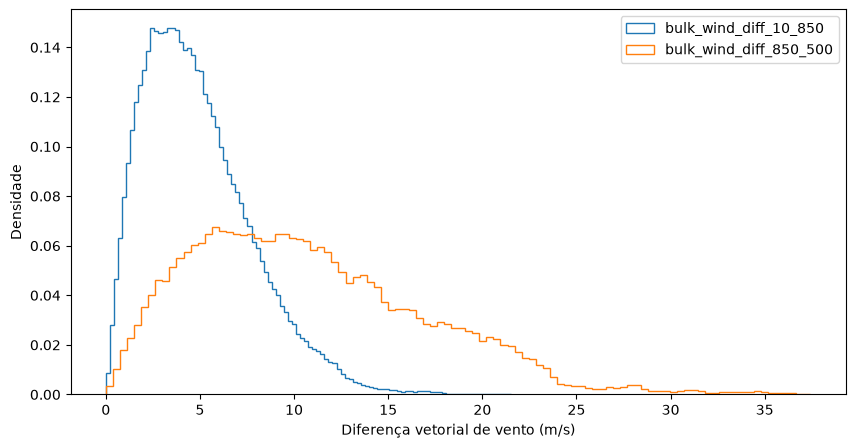

In [9]:
if samples is not None:
    fig, ax=plt.subplots(figsize=(10,5))
    for name in ["bulk_wind_diff_10_850","bulk_wind_diff_850_500"]:
        ax.hist(samples[name],bins=100,density=True,histtype="step",label=name)
    ax.set_xlabel("Diferença vetorial de vento (m/s)")
    ax.set_ylabel("Densidade")
    ax.legend(); plt.show()

## 8. Correlação entre diagnósticos derivados

Esta matriz serve apenas para identificar possível redundância entre diagnósticos; a análise multivariada formal será realizada mais adiante.

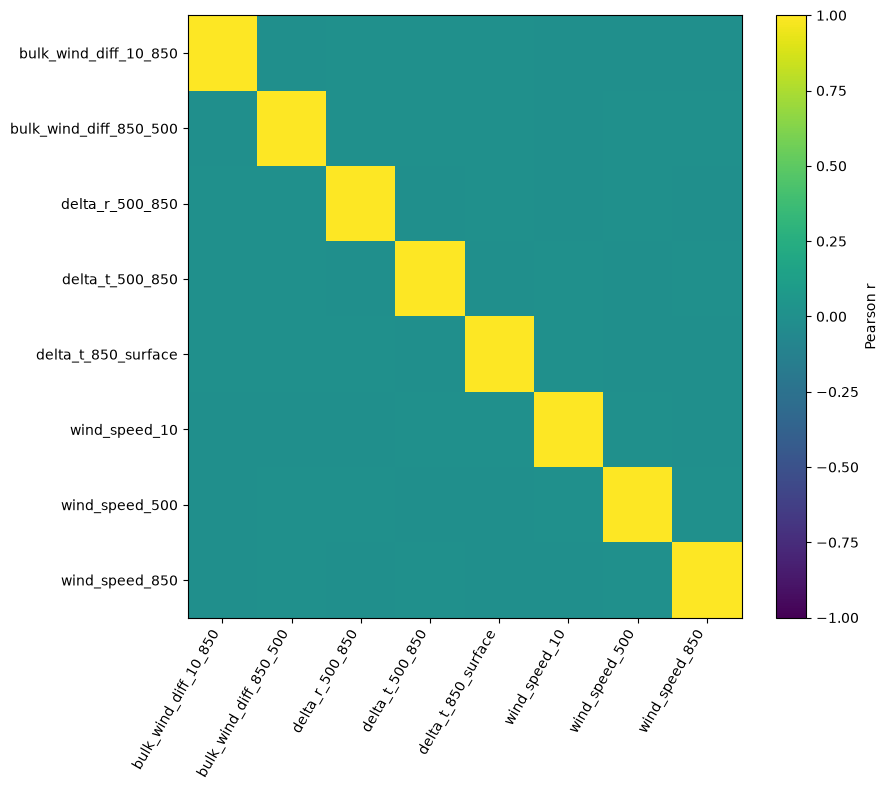

In [12]:
if not corr_long.empty:
    mat=corr_long.pivot(index="var_a",columns="var_b",values="pearson_r")
    fig,ax=plt.subplots(figsize=(9,8))
    im=ax.imshow(mat.values,vmin=-1,vmax=1,aspect="auto")
    ax.set_xticks(range(len(mat.columns)),mat.columns,rotation=60,ha="right")
    ax.set_yticks(range(len(mat.index)),mat.index)
    fig.colorbar(im,ax=ax,label="Pearson r")
    fig.tight_layout(); plt.show()

## 9. Síntese da Fase 2

In [13]:
check = pd.DataFrame([
    {"checagem":"Variáveis derivadas calculadas","status":"OK" if len(derived)>=8 else "REVISAR","detalhe":len(derived)},
    {"checagem":"Amostras para visualização","status":"OK" if samples is not None else "REVISAR","detalhe":str(samples_file)},
    {"checagem":"Catálogo de fórmulas","status":"OK" if len(formulas)>=8 else "REVISAR","detalhe":len(formulas)},
])
check

,checagem,status,detalhe
0,Variáveis derivadas calculadas,OK,8
1,Amostras para visualização,OK,/home/vsantos/repositories/rionowcastdf/analys...
2,Catálogo de fórmulas,OK,8
